## 0. Setup

Continue with the notebook1, here we input the cleaned dataset.

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# ---------- paths ----------
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA_PROCESSED = PROJECT_ROOT / "data" / "processed"
FIGURES = PROJECT_ROOT / "outputs" / "figures"
FIGURES.mkdir(parents=True, exist_ok=True)

# ---------- load + map drug names + filter ----------
df_raw = pd.read_csv(DATA_PROCESSED / "df_clean_wide.csv")

compound_mapping = pd.DataFrame({
    "Metadata_JCP2022": ["JCP2022_033924", "JCP2022_095995", "JCP2022_001418",
                         "JCP2022_094347", "JCP2022_051785"],
    "drug_name":        ["DMSO", "hydroxyurea", "palbociclib", "etoposide", "resveratrol"],
    "category":         ["control", "senescence_inducer", "senescence_inducer",
                         "senescence_inducer", "seno_modulator"],
})
df_raw = df_raw.merge(compound_mapping, on="Metadata_JCP2022", how="left")

# 3-stage filter exactly as in notebook 01 / Emiliya's R code
df_filt = df_raw[
    (df_raw["Cells_AreaShape_FormFactor"]   <= 1) &
    (df_raw["Nuclei_AreaShape_FormFactor"]  <= 1) &
    (df_raw["Cells_AreaShape_EulerNumber"]  == 1) &
    (df_raw["Nuclei_AreaShape_EulerNumber"] == 1) &
    (df_raw["NC_Ratio"]                     <= 1) &
    (df_raw["NC_Ratio_Radius"]              <= 1)
].copy()

print(f"Unfiltered: {len(df_raw):>7} cells")
print(f"Filtered:   {len(df_filt):>7} cells (-{len(df_raw) - len(df_filt)}, {(len(df_raw) - len(df_filt))/len(df_raw)*100:.1f}%)")

Unfiltered:  113197 cells
Filtered:    102430 cells (-10767, 9.5%)


In [7]:
DRUG_ORDER  = ["DMSO", "hydroxyurea", "palbociclib", "etoposide", "resveratrol"]
DRUG_COLORS = {
    "DMSO":         "#666666",   # grey  — control
    "hydroxyurea":  "#D4A017",   # gold  — readable yellow
    "palbociclib":  "#FF7F0E",   # orange
    "etoposide":    "#D81B82",   # magenta
    "resveratrol":  "#D62728",   # red
}
# Tell seaborn to use our palette by default for any drug-colored plot.
sns.set_theme(style="whitegrid")


## 2. Cells per drug after filter removing (refer to slide 25)

This is Emiliya's first quantitative summary slide.

**Plotting concepts introduced here:**

- `sns.barplot` for the bars themselves.
- `plt.subplots(figsize=...)` to control figure size.
- `ax.bar_label` to write numbers on top of each bar.
- `plt.savefig(..., dpi=200, bbox_inches='tight')` to export at presentation quality (`bbox_inches='tight'` trims whitespace; `dpi=200` is fine for slides — use `dpi=300` if a journal asks).

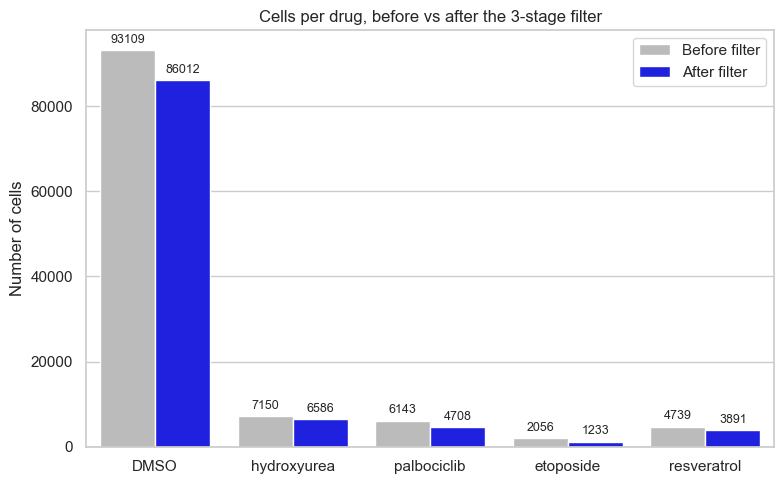

     drug_name  n_before  n_after  n_removed  pct_removed
0         DMSO     93109    86012       7097     7.622249
1    etoposide      2056     1233        823    40.029183
2  hydroxyurea      7150     6586        564     7.888112
3  palbociclib      6143     4708       1435    23.359922
4  resveratrol      4739     3891        848    17.894070


In [25]:
# Group drugs, each report the before filter and after filter.
counts_before = df_raw.groupby("drug_name").size().reset_index(name="n").assign(state="Before filter")
counts_after  = df_filt.groupby("drug_name").size().reset_index(name="n").assign(state="After filter")
bar_df = pd.concat([counts_before, counts_after], ignore_index=True)

# draw the bar plot.
fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(
    data=bar_df,
    x="drug_name", y="n", hue="state",
    order=DRUG_ORDER,
    hue_order=["Before filter", "After filter"],
    palette={"Before filter": "#BBBBBB", "After filter": "#0000FF"},
    ax=ax,
)
# Add the count number on top of each bar.
for container in ax.containers:
    ax.bar_label(container, fmt="%d", padding=3, fontsize=9)

ax.set_xlabel("")
ax.set_ylabel("Number of cells")
ax.set_title("Cells per drug, before vs after the 3-stage filter")
ax.legend(title="", loc="upper right")
plt.tight_layout()

# Save figure first, and then show below.
fig.savefig(FIGURES / "cells_per_drug_before_after.png", dpi=200, bbox_inches="tight")
plt.show()

# Compute removed counts and removed percentage per drug
filter_loss_df = counts_before[["drug_name", "n"]].rename(columns={"n": "n_before"}).merge(
    counts_after[["drug_name", "n"]].rename(columns={"n": "n_after"}),
    on="drug_name",
    how="left"
)

filter_loss_df["n_after"] = filter_loss_df["n_after"].fillna(0).astype(int)
filter_loss_df["n_removed"] = filter_loss_df["n_before"] - filter_loss_df["n_after"]
filter_loss_df["pct_removed"] = filter_loss_df["n_removed"] / filter_loss_df["n_before"] * 100

filter_loss_df = filter_loss_df.sort_values("drug_name")
print(filter_loss_df)


## 3. Per-feature stacked histograms (slides 19–24)


In [10]:
# The 16 AreaShape features (8 each for Cells and Nuclei) plus the two ratios.
# To Hayden: This is Emiliya's selection of features, we could apply more features later. 
plot_features = [
    "Cells_AreaShape_BoundingBoxArea",  "Cells_AreaShape_Compactness",
    "Cells_AreaShape_Eccentricity",     "Cells_AreaShape_EulerNumber",
    "Cells_AreaShape_FormFactor",       "Cells_AreaShape_MeanRadius",
    "Cells_AreaShape_Perimeter",        "Cells_AreaShape_Solidity",
    "Nuclei_AreaShape_BoundingBoxArea", "Nuclei_AreaShape_Compactness",
    "Nuclei_AreaShape_Eccentricity",    "Nuclei_AreaShape_EulerNumber",
    "Nuclei_AreaShape_FormFactor",      "Nuclei_AreaShape_MeanRadius",
    "Nuclei_AreaShape_Perimeter",       "Nuclei_AreaShape_Solidity",
    "NC_Ratio",                         "NC_Ratio_Radius",
]

def plot_feature_histograms(data, title, save_name):
    """Plot a 6x3 grid of stacked histograms, one per feature."""
    n = len(plot_features)
    ncols = 3
    nrows = (n + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(15, 3 * nrows))
    axes = axes.flatten()              
    for ax, feat in zip(axes, plot_features):
        sns.histplot(
            data=data, x=feat,
            hue="drug_name", hue_order=DRUG_ORDER, palette=DRUG_COLORS,
            multiple="stack", bins=50, ax=ax, legend=False,
        )
        ax.set_title(feat.replace("_AreaShape", "").replace("_", " "))
        ax.set_xlabel("")
        ax.set_ylabel("count")
        
    # Hide any leftover axes (if features < grid slots)
    for ax in axes[len(plot_features):]:
        ax.set_visible(False)
        
    # Single shared legend across the whole figure.
    handles = [plt.Rectangle((0, 0), 1, 1, color=DRUG_COLORS[d]) for d in DRUG_ORDER]
    fig.legend(handles, DRUG_ORDER, loc="lower center", ncol=5, bbox_to_anchor=(0.5, -0.02))
    fig.suptitle(title, fontsize=14, y=1.0)
    plt.tight_layout()
    fig.savefig(FIGURES / save_name, dpi=200, bbox_inches="tight")
    plt.show()


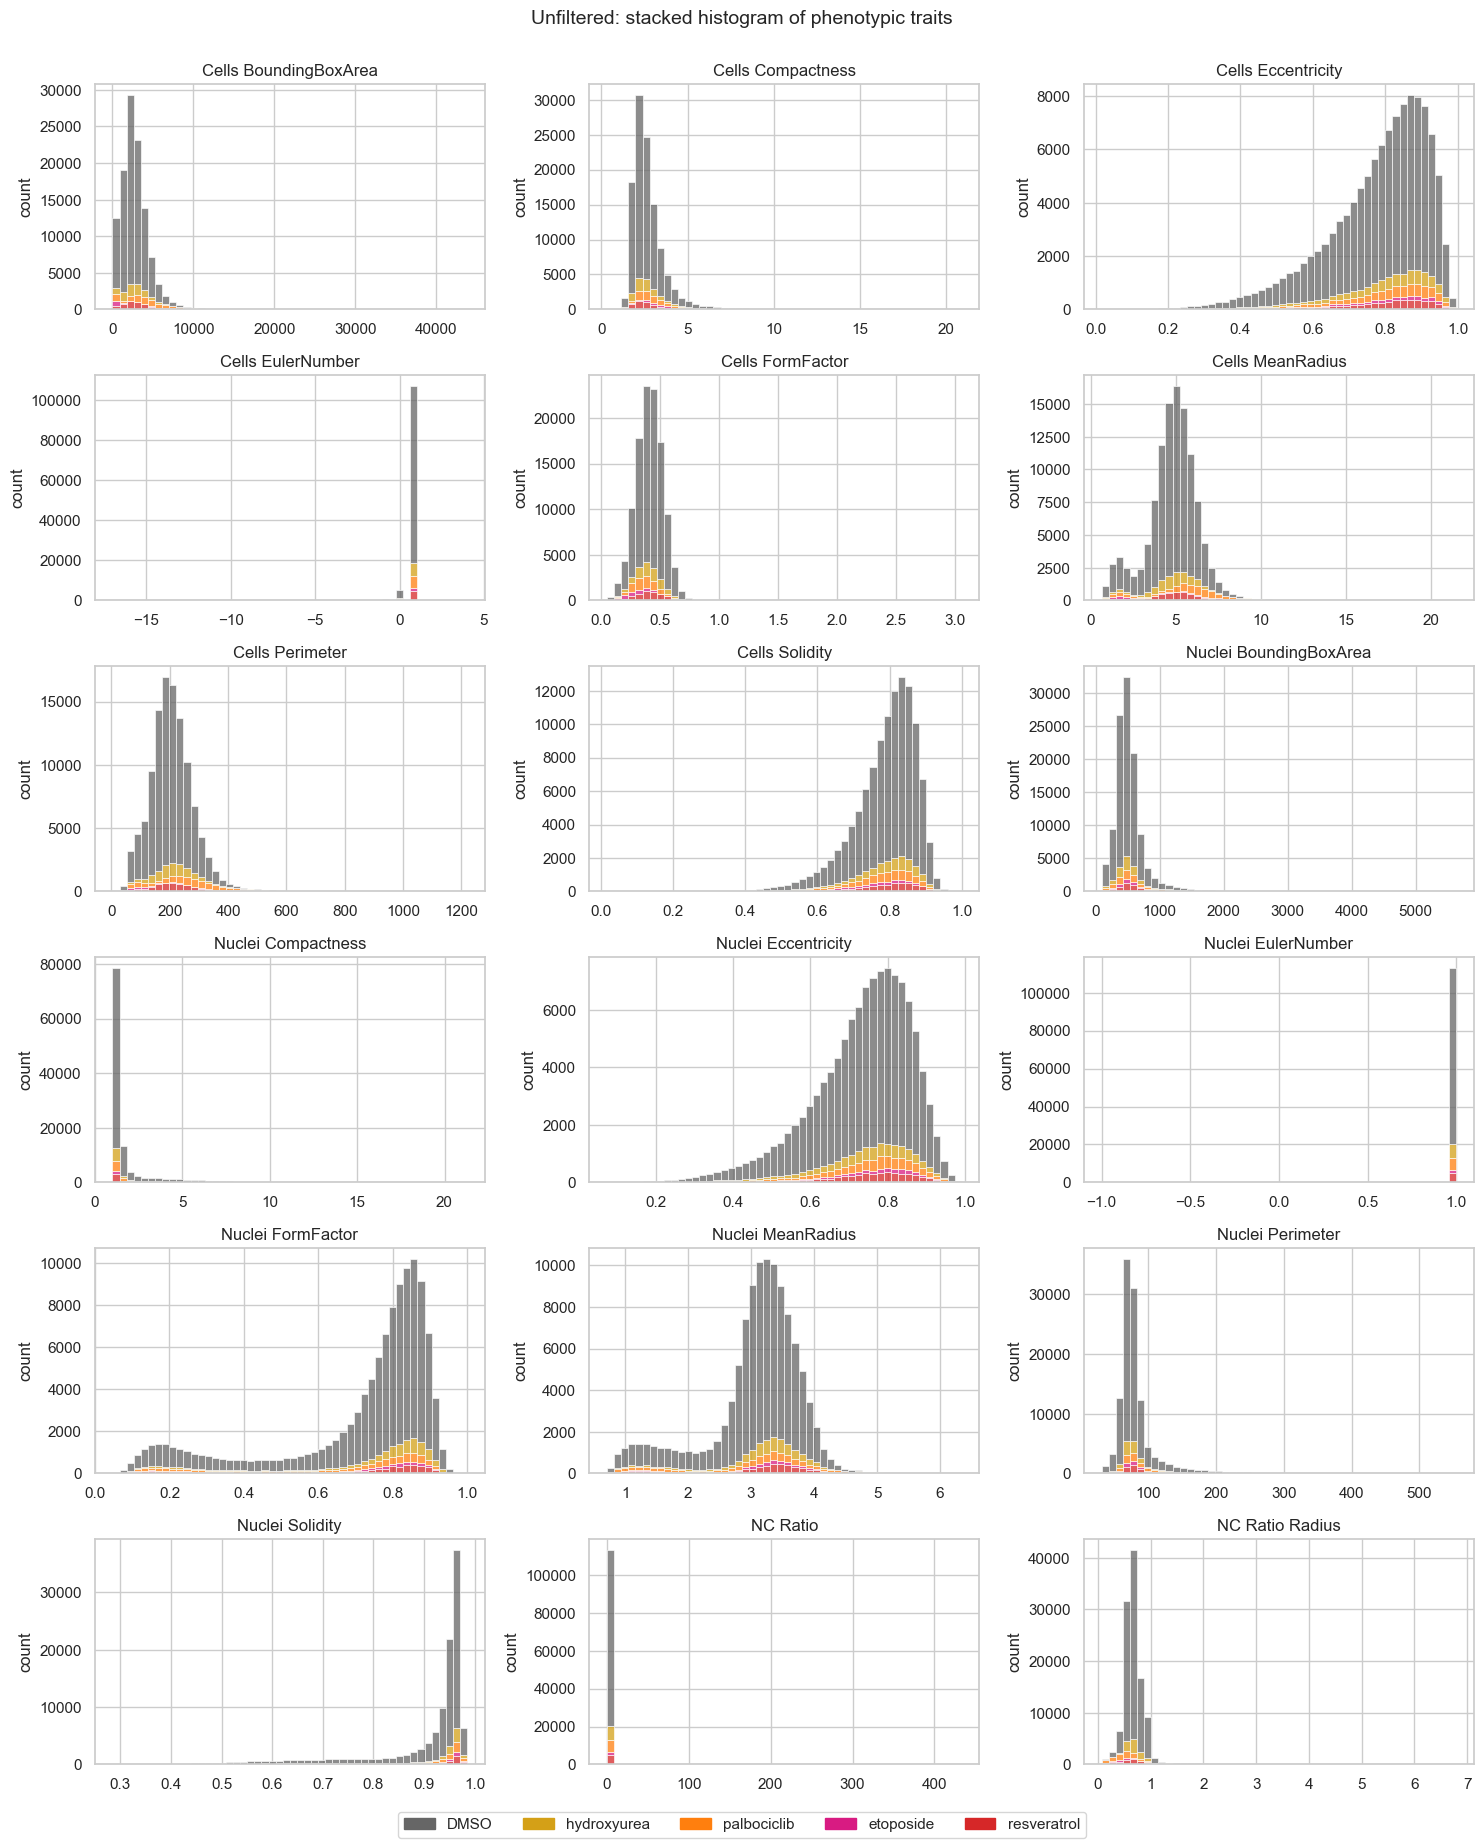

In [11]:
# Unfiltered histograms — refer to the plot in slides 19-21 in Emiliya's presentation.
plot_feature_histograms(
    data=df_raw,
    title="Unfiltered: stacked histogram of phenotypic traits",
    save_name="histograms_unfiltered.png",
)


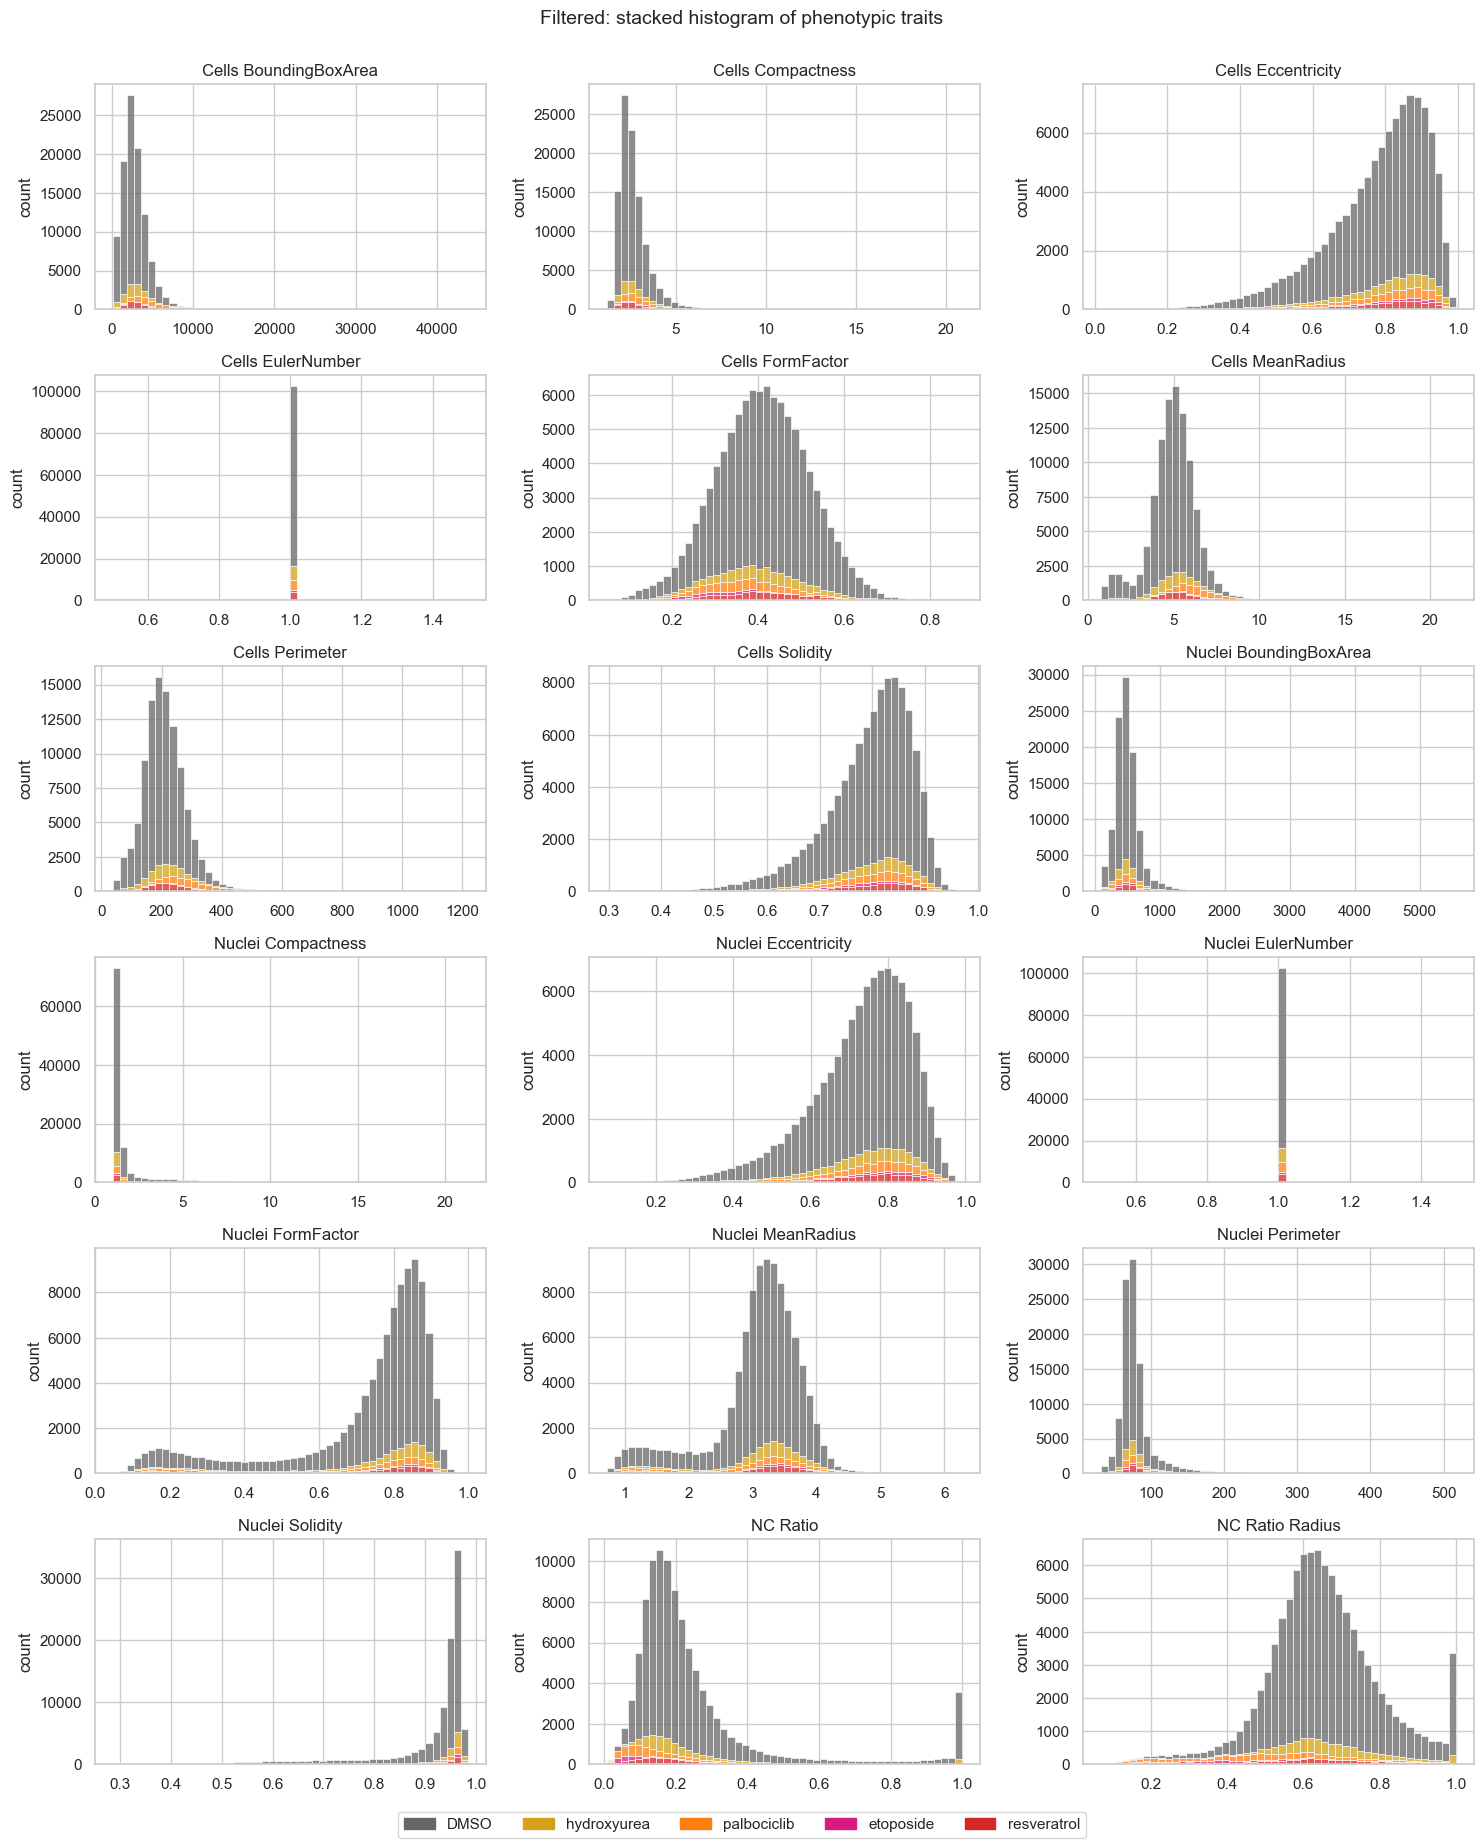

In [12]:
# Filtered histograms — refer to the plot in slides 22-24 in Emiliya's presentation.
plot_feature_histograms(
    data=df_filt,
    title="Filtered: stacked histogram of phenotypic traits",
    save_name="histograms_filtered.png",
)


## 4. Per-drug violin plots (slides 28–33)
Here I pick the six features Emiliya highlights in her slides: cell size (`BoundingBoxArea`, `MeanRadius`, `Perimeter`), nucleus size (`Nuclei_BoundingBoxArea`), N/C ratios, and a shape feature (`Solidity`).

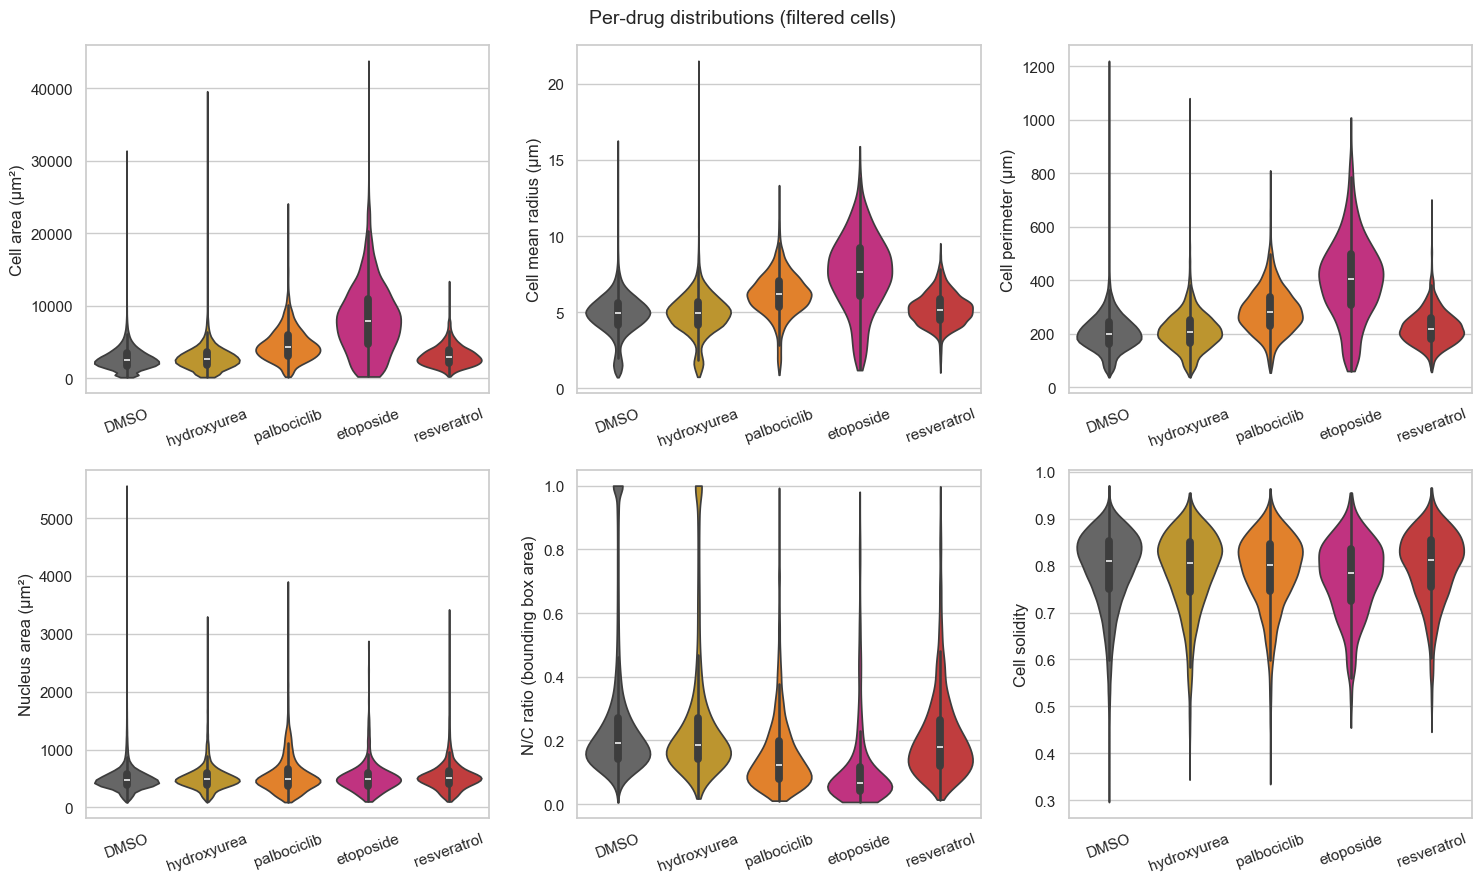

In [15]:
violin_features = [
    ("Cells_AreaShape_BoundingBoxArea", "Cell area (μm²)"),
    ("Cells_AreaShape_MeanRadius",      "Cell mean radius (μm)"),
    ("Cells_AreaShape_Perimeter",       "Cell perimeter (μm)"),
    ("Nuclei_AreaShape_BoundingBoxArea","Nucleus area (μm²)"),
    ("NC_Ratio",                        "N/C ratio (bounding box area)"),
    ("Cells_AreaShape_Solidity",        "Cell solidity"),
]

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.flatten()

for ax, (feat, label) in zip(axes, violin_features):
    sns.violinplot(
        data=df_filt, x="drug_name", y=feat,
        order=DRUG_ORDER, palette=DRUG_COLORS,
        cut=0,                
        inner="box",          
        ax=ax, hue="drug_name", legend=False,
    )
    ax.set_xlabel("")
    ax.set_ylabel(label)
    ax.tick_params(axis="x", rotation=20)

fig.suptitle("Per-drug distributions (filtered cells)", fontsize=14)
plt.tight_layout()
fig.savefig(FIGURES / "violins_per_drug.png", dpi=200, bbox_inches="tight")
plt.show()


**There are some biological oberservations:**

- **Cell area / radius / perimeter** : inducer-treated cells (`palbociclib`, `etoposide`) have visibly fatter violins shifted to the right of DMSO. These maybe some strong signal that could use for classification.
- **Nucleus area** : the shift is smaller. Nuclei don't grow as much as the surrounding cell.
- **N/C ratio** : because cell grows but nucleus doesn't, the ratio drops for inducer-treated cells. This matches slide 31.
- **Cell solidity** : inducer-treated cells have lower solidity.


## 5. Statistical comparison: ANOVA + Tukey HSD + Dunnett's test(slides 43–44)

**NOTE:** since ANOVA assumes the observations are independent. But here, cells from the same well are not independent (they were grown together and I am somewhat thought we should make a further considering for this), so the p-values from cell-level ANOVA could be over-confident. And the real effective sample size may closer to the number of wells than the number of cells. For now I just reproducing what Emiliya did, and to follow her idea to make sure at first step I could understand this project. But I think this question we should discuss later.

In [29]:
from scipy.stats import f_oneway, tukey_hsd, dunnett

group_names = DRUG_ORDER
tukey_rows = []

for feat, label in violin_features:
    # Split this feature's values into one array per drug, in DRUG_ORDER.
    samples = [df_filt.loc[df_filt["drug_name"] == d, feat].values for d in group_names]

    # ---- 1. One-way ANOVA ----
    F, p_anova = f_oneway(*samples)

    # ---- 2. Tukey HSD post-hoc ----
    res = tukey_hsd(*samples)
    # res.statistic[i, j] is the mean difference (mean_i - mean_j); res.pvalue[i, j] is the adjusted p-value.

    dmso_idx = group_names.index("DMSO")
    for j, drug in enumerate(group_names):
        if drug == "DMSO":
            continue
        meandiff = res.statistic[j, dmso_idx]    
        pval     = res.pvalue[j, dmso_idx]
        tukey_rows.append({
            "feature":     feat,
            "treatment":   drug,
            "vs_control":  "DMSO",
            "anova_F":     F,
            "anova_p":     p_anova,
            "tukey_meandiff_vs_dmso": meandiff,
            "tukey_p_adj": pval,
            "significant": pval < 0.05,
        })

tukey_df = pd.DataFrame(tukey_rows)
tukey_df



,feature,treatment,vs_control,anova_F,anova_p,tukey_meandiff_vs_dmso,tukey_p_adj,significant
0,Cells_AreaShape_BoundingBoxArea,hydroxyurea,DMSO,4928.809158,0.000000e+00,125.277871,2.382862e-08,True
1,Cells_AreaShape_BoundingBoxArea,palbociclib,DMSO,4928.809158,0.000000e+00,1997.114937,0.000000e+00,True
2,Cells_AreaShape_BoundingBoxArea,etoposide,DMSO,4928.809158,0.000000e+00,5472.236951,0.000000e+00,True
3,Cells_AreaShape_BoundingBoxArea,resveratrol,DMSO,4928.809158,0.000000e+00,429.290014,0.000000e+00,True
4,Cells_AreaShape_MeanRadius,hydroxyurea,DMSO,2366.448360,0.000000e+00,0.029329,4.325898e-01,False
5,Cells_AreaShape_MeanRadius,palbociclib,DMSO,2366.448360,0.000000e+00,1.348893,0.000000e+00,True
6,Cells_AreaShape_MeanRadius,etoposide,DMSO,2366.448360,0.000000e+00,2.743614,0.000000e+00,True
7,Cells_AreaShape_MeanRadius,resveratrol,DMSO,2366.448360,0.000000e+00,0.402508,0.000000e+00,True
8,Cells_AreaShape_Perimeter,hydroxyurea,DMSO,4150.255187,0.000000e+00,6.219451,1.841416e-11,True
9,Cells_AreaShape_Perimeter,palbociclib,DMSO,4150.255187,0.000000e+00,83.413185,0.000000e+00,True


Almost every comparison rejects. There ara two potential reasons:
1. Real biological effects.
2. Massive sample sizes (90k+ DMSO cells means even tiny mean differences are "significant"). Sample-size-driven p-values are why you should always look at *effect sizes* (`meandiff`) alongside *p-values*.

In [31]:
# Dunnett's test is designed for treatment-vs-control comparisons.
# Here, DMSO is the control group.
control_name = "DMSO"
treatment_names = [d for d in DRUG_ORDER if d != control_name]

dunnett_rows = []

for feat, label in violin_features:
    control_sample = df_filt.loc[df_filt["drug_name"] == control_name, feat].values
    
    treatment_samples = [
        df_filt.loc[df_filt["drug_name"] == drug, feat].values
        for drug in treatment_names
    ]

    # Dunnett's test compares each treatment sample against the control sample.
    res = dunnett(
        *treatment_samples,
        control=control_sample,
        alternative="two-sided"
    )

    for i, drug in enumerate(treatment_names):
        treatment_sample = treatment_samples[i]
        
        # Mean difference: treatment mean minus DMSO mean
        meandiff = treatment_sample.mean() - control_sample.mean()
        
        dunnett_rows.append({
            "feature": feat,
            "treatment": drug,
            "vs_control": control_name,
            "dunnett_meandiff_vs_dmso": meandiff,
            "dunnett_statistic": res.statistic[i],
            "dunnett_p_adj": res.pvalue[i],
            "dunnett_significant": res.pvalue[i] < 0.05,
        })

dunnett_df = pd.DataFrame(dunnett_rows)
dunnett_df



,feature,treatment,vs_control,dunnett_meandiff_vs_dmso,dunnett_statistic,dunnett_p_adj,dunnett_significant
0,Cells_AreaShape_BoundingBoxArea,hydroxyurea,DMSO,125.277871,5.969087,9.575038e-09,True
1,Cells_AreaShape_BoundingBoxArea,palbociclib,DMSO,1997.114937,81.281783,0.000000e+00,True
2,Cells_AreaShape_BoundingBoxArea,etoposide,DMSO,5472.236951,116.225017,0.000000e+00,True
3,Cells_AreaShape_BoundingBoxArea,resveratrol,DMSO,429.290014,15.955770,0.000000e+00,True
4,Cells_AreaShape_MeanRadius,hydroxyurea,DMSO,0.029329,1.702074,3.099827e-01,False
5,Cells_AreaShape_MeanRadius,palbociclib,DMSO,1.348893,66.867048,0.000000e+00,True
6,Cells_AreaShape_MeanRadius,etoposide,DMSO,2.743614,70.974515,0.000000e+00,True
7,Cells_AreaShape_MeanRadius,resveratrol,DMSO,0.402508,18.221568,0.000000e+00,True
8,Cells_AreaShape_Perimeter,hydroxyurea,DMSO,6.219451,7.045980,7.412293e-12,True
9,Cells_AreaShape_Perimeter,palbociclib,DMSO,83.413185,80.719921,0.000000e+00,True


In [32]:
comparison_df = tukey_df.merge(
    dunnett_df,
    on=["feature", "treatment", "vs_control"],
    how="left"
)

comparison_df

,feature,treatment,vs_control,anova_F,anova_p,tukey_meandiff_vs_dmso,tukey_p_adj,significant,dunnett_meandiff_vs_dmso,dunnett_statistic,dunnett_p_adj,dunnett_significant
0,Cells_AreaShape_BoundingBoxArea,hydroxyurea,DMSO,4928.809158,0.000000e+00,125.277871,2.382862e-08,True,125.277871,5.969087,9.575038e-09,True
1,Cells_AreaShape_BoundingBoxArea,palbociclib,DMSO,4928.809158,0.000000e+00,1997.114937,0.000000e+00,True,1997.114937,81.281783,0.000000e+00,True
2,Cells_AreaShape_BoundingBoxArea,etoposide,DMSO,4928.809158,0.000000e+00,5472.236951,0.000000e+00,True,5472.236951,116.225017,0.000000e+00,True
3,Cells_AreaShape_BoundingBoxArea,resveratrol,DMSO,4928.809158,0.000000e+00,429.290014,0.000000e+00,True,429.290014,15.955770,0.000000e+00,True
4,Cells_AreaShape_MeanRadius,hydroxyurea,DMSO,2366.448360,0.000000e+00,0.029329,4.325898e-01,False,0.029329,1.702074,3.099827e-01,False
5,Cells_AreaShape_MeanRadius,palbociclib,DMSO,2366.448360,0.000000e+00,1.348893,0.000000e+00,True,1.348893,66.867048,0.000000e+00,True
6,Cells_AreaShape_MeanRadius,etoposide,DMSO,2366.448360,0.000000e+00,2.743614,0.000000e+00,True,2.743614,70.974515,0.000000e+00,True
7,Cells_AreaShape_MeanRadius,resveratrol,DMSO,2366.448360,0.000000e+00,0.402508,0.000000e+00,True,0.402508,18.221568,0.000000e+00,True
8,Cells_AreaShape_Perimeter,hydroxyurea,DMSO,4150.255187,0.000000e+00,6.219451,1.841416e-11,True,6.219451,7.045980,7.412293e-12,True
9,Cells_AreaShape_Perimeter,palbociclib,DMSO,4150.255187,0.000000e+00,83.413185,0.000000e+00,True,83.413185,80.719921,0.000000e+00,True


## 6. Summary

This notebook successfully reproduced the main exploratory plots and cell-level statistical comparisons from the Emiliya analysis. The results showed that filtering had an uneven effect on different drugs, especially with etoposide having a significant number of cells filtered out. Violin plots showed a significant increase in cell-size features for etoposide and palbociclib, while the N/C ratio decreased. ANOVA, Tukey HSD, and Dunnett’s test provided preliminary statistical comparisons, but since the analysis was still at the cell level, the p-values ​​should be interpreted as exploratory, and further well-level analysis is needed.
